<a href="https://colab.research.google.com/github/abdul-zabbar04/22.5_23.5_simply_bank/blob/main/health_monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os
from tqdm import tqdm

In [ ]:
signals_folder = "/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/signals/"
numerics_folder = "/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/numerics/"
output_file = "/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/big_merged_dataset.csv"

In [ ]:
all_signals_list = []
all_numerics_list = []

In [ ]:
for i in tqdm(range(1, 54)):
    num_str = f"{i:02d}"   # '01', '02', ...

    # Signals লোড
    sig_path = os.path.join(signals_folder, f"bidmc_{num_str}_Signals.csv")
    if os.path.exists(sig_path):
        df_sig = pd.read_csv(sig_path)
        # আসল কলাম নাম দিয়ে রাখা (স্পেস সহ!)
        df_sig = df_sig[['Time [s]', ' PLETH', ' II']].copy()
        df_sig['subject_id'] = i
        all_signals_list.append(df_sig)
    else:
        print(f"Warning: {sig_path} not found!")

    # Numerics লোড
    num_path = os.path.join(numerics_folder, f"bidmc_{num_str}_Numerics.csv")
    if os.path.exists(num_path):
        df_num = pd.read_csv(num_path)
        # Numerics-এ কলাম নামে স্পেস নেই (তোমার আগের আউটপুট অনুসারে)
        df_num = df_num[['Time [s]', ' HR', ' SpO2']].copy()
        df_num['subject_id'] = i
        all_numerics_list.append(df_num)
    else:
        print(f"Warning: {num_path} not found!")

100%|██████████| 53/53 [00:42<00:00,  1.26it/s]


In [ ]:
big_signals = pd.concat(all_signals_list, ignore_index=True)
big_numerics = pd.concat(all_numerics_list, ignore_index=True)

In [ ]:
big_signals.shape

(3180053, 4)

In [ ]:
big_numerics.shape

(25493, 4)

In [ ]:
merged_df = pd.merge(
    big_signals,
    big_numerics,
    on=['subject_id', 'Time [s]'],
    how='left'
)

/tmp/ipykernel_20520/2580274945.py:1: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  merged_df = pd.merge(


In [ ]:
print("Final merged shape:", merged_df.shape)
print("প্রথম ৫টা রো:")
print(merged_df.head())
print("শেষ ৫টা রো:")
print(merged_df.tail())

merged_df.to_csv(output_file, index=False)
print(f"সম্পূর্ণ হয়েছে! ফাইল সেভ হয়েছে: {output_file}")

Final merged shape: (3180053, 6)
প্রথম ৫টা রো:
   Time [s]    PLETH       II  subject_id    HR   SpO2
0     0.000  0.43597  0.72549           1  94.0   97.0
1     0.008  0.43206  0.67059           1   NaN    NaN
2     0.016  0.42815  0.60980           1   NaN    NaN
3     0.024  0.42424  0.55098           1   NaN    NaN
4     0.032  0.42131  0.50000           1   NaN    NaN
শেষ ৫টা রো:
         Time [s]   PLETH       II  subject_id    HR   SpO2
3180048    479.97  1.2962  0.27468          53   NaN    NaN
3180049    479.98  1.2884  0.26002          53   NaN    NaN
3180050    479.98  1.2786  0.25464          53   NaN    NaN
3180051    479.99  1.2678  0.22972          53   NaN    NaN
3180052    480.00  1.2571  0.31476          53  94.0  100.0
সম্পূর্ণ হয়েছে! ফাইল সেভ হয়েছে: /content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/big_merged_dataset.csv


📂 ডেটা লোড করা হচ্ছে...
✅ Columns after rename: ['Time [s]', 'PPG', 'ECG', 'subject_id', 'HR', 'SpO2']

📊 Before vs After Filtering গ্রাফ তৈরি করা হচ্ছে...
✅ গ্রাফ সেভ হয়েছে: /content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/before_after_filtering.png


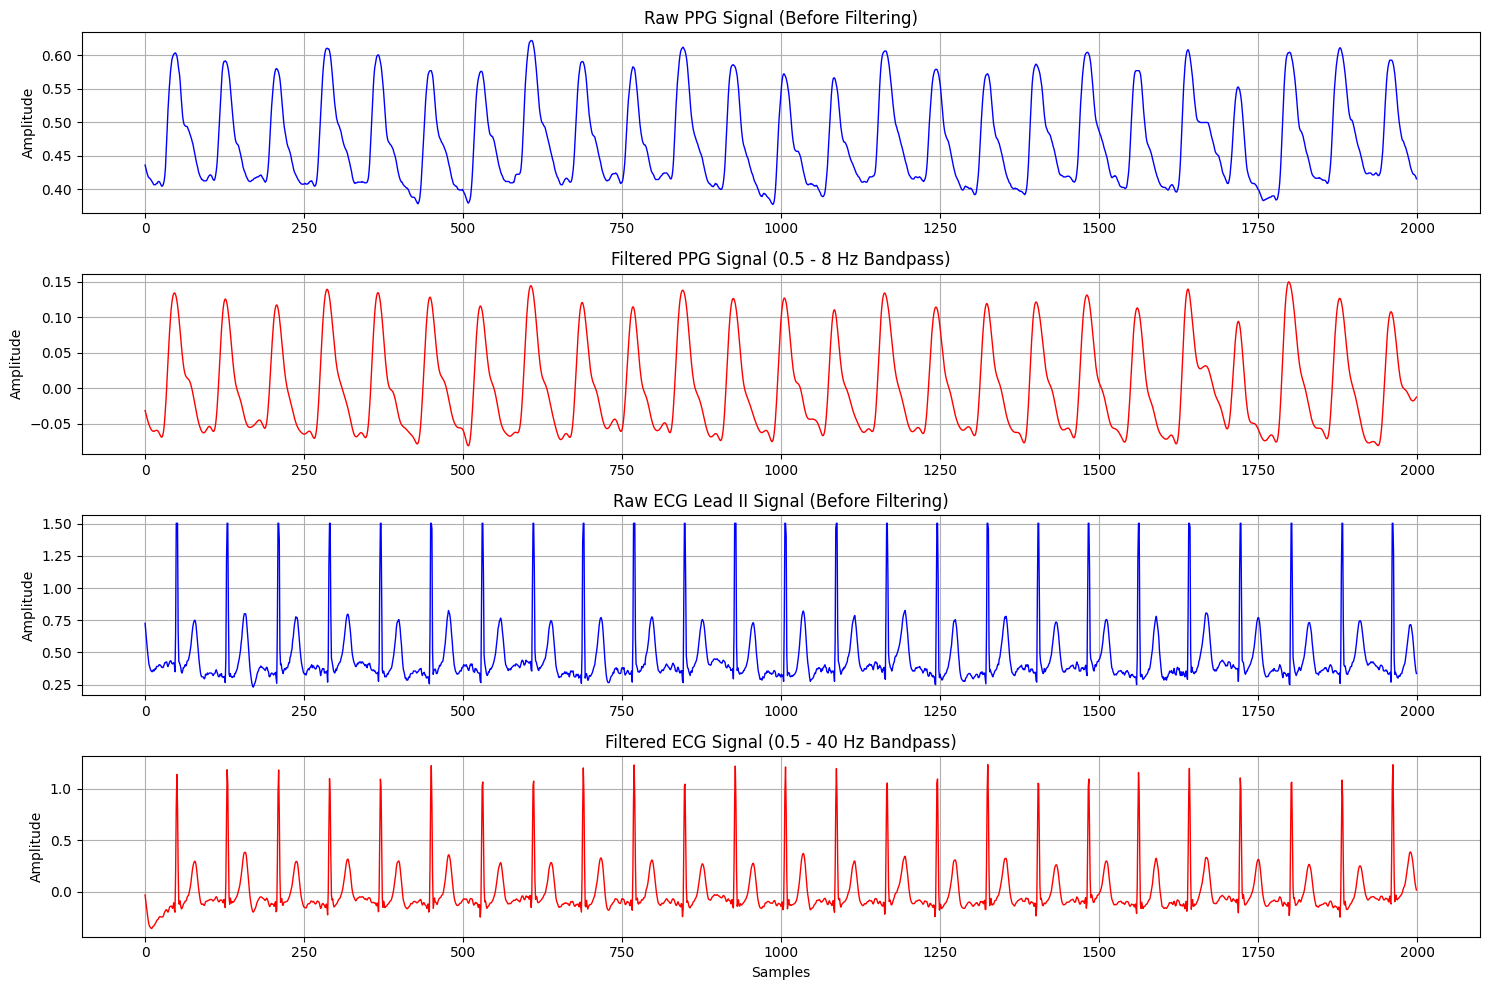


🔄 ফিল্টার করা PPG এবং ECG কলাম যোগ করা হচ্ছে...


/tmp/ipykernel_20520/2876477398.py:90: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_df = merged_df.groupby('subject_id', group_keys=False).apply(apply_filter_to_column)


✅ ফিল্টার করা ডেটাসেট সেভ হয়েছে: big_merged_dataset_filtered.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from tqdm import tqdm

# ====================== 1. ডেটা লোড করা ======================
print("📂 ডেটা লোড করা হচ্ছে...")
file_path = "/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/big_merged_dataset.csv"
merged_df = pd.read_csv(file_path)

# কলাম নাম ঠিক করা (স্পেস সহ নামগুলো ফিক্স করা)
merged_df = merged_df.rename(columns={
    ' PLETH': 'PPG',
    ' II': 'ECG',
    ' HR': 'HR',
    ' SpO2': 'SpO2'
})

print("✅ Columns after rename:", merged_df.columns.tolist())

# ====================== 2. ফিল্টার ফাংশন ======================
def bandpass_filter(data, lowcut=0.5, highcut=8.0, fs=125.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    y = signal.filtfilt(b, a, data)
    return y

# ====================== 3. একটা সাবজেক্ট নিয়ে Before-After গ্রাফ ======================
print("\n📊 Before vs After Filtering গ্রাফ তৈরি করা হচ্ছে...")

# Subject 1 থেকে ২০০০ স্যাম্পল নেওয়া (প্রায় ১৬ সেকেন্ড)
sample_df = merged_df[merged_df['subject_id'] == 1].copy().iloc[:2000]

raw_ppg = sample_df['PPG'].values
raw_ecg = sample_df['ECG'].values

# Filtering
filtered_ppg = bandpass_filter(raw_ppg, lowcut=0.5, highcut=8.0, fs=125)
filtered_ecg = bandpass_filter(raw_ecg, lowcut=0.5, highcut=40.0, fs=125)

# ====================== 4. গ্রাফ প্লট করা ======================
plt.figure(figsize=(15, 10))

plt.subplot(4, 1, 1)
plt.plot(raw_ppg, color='blue', linewidth=1)
plt.title('Raw PPG Signal (Before Filtering)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(filtered_ppg, color='red', linewidth=1)
plt.title('Filtered PPG Signal (0.5 - 8 Hz Bandpass)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(raw_ecg, color='blue', linewidth=1)
plt.title('Raw ECG Lead II Signal (Before Filtering)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(filtered_ecg, color='red', linewidth=1)
plt.title('Filtered ECG Signal (0.5 - 40 Hz Bandpass)')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()

# গ্রাফ সেভ করা (থিসিসে ব্যবহার করার জন্য)
save_path = "/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/before_after_filtering.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ গ্রাফ সেভ হয়েছে: {save_path}")

plt.show()

# ====================== 5. ফিল্টার করা ডেটা সেভ করা (ঐচ্ছিক) ======================
print("\n🔄 ফিল্টার করা PPG এবং ECG কলাম যোগ করা হচ্ছে...")

# পুরো ডেটাসেটে ফিল্টার প্রয়োগ (এটা একটু সময় নিতে পারে)
def apply_filter_to_column(group):
    group['PPG_filtered'] = bandpass_filter(group['PPG'].values)
    group['ECG_filtered'] = bandpass_filter(group['ECG'].values, highcut=40.0)
    return group

merged_df = merged_df.groupby('subject_id', group_keys=False).apply(apply_filter_to_column)

# ফাইনাল ফিল্টার করা ডেটাসেট সেভ
merged_df.to_csv("/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/big_merged_dataset_filtered.csv", index=False)
print("✅ ফিল্টার করা ডেটাসেট সেভ হয়েছে: big_merged_dataset_filtered.csv")

In [ ]:
merged_df[123: 252]

,Time [s],PLETH,II,subject_id,HR,SpO2
123,0.984,0.58749,0.30392,1,NaN,NaN
124,0.992,0.59042,0.30980,1,NaN,NaN
125,1.000,0.59042,0.31373,1,94.0,97.0
126,1.008,0.59140,0.26471,1,NaN,NaN
127,1.016,0.59042,0.45490,1,NaN,NaN
...,...,...,...,...,...,...
247,1.976,0.40762,0.39020,1,NaN,NaN
248,1.984,0.40762,0.36471,1,NaN,NaN
249,1.992,0.40762,0.34510,1,NaN,NaN
250,2.000,0.40762,0.33529,1,94.0,97.0


In [ ]:
merged_df.columns

Index(['Time [s]', ' PLETH', ' II', 'subject_id', ' HR', ' SpO2'], dtype='object')

In [ ]:
# Step 8: NaN ফিল করা + Time [s] ক্লিন করা

# Time [s] কে float-এ নিশ্চিত করা (warning এড়াতে)
merged_df['Time [s]'] = merged_df['Time [s]'].astype(float)

# প্রত্যেক subject_id-এর ভিতরে group করে forward fill করা
# (যাতে এক সাবজেক্টের NaN অন্য সাবজেক্টের ডেটা দিয়ে ফিল না হয়)
merged_df = merged_df.sort_values(['subject_id', 'Time [s]'])
merged_df[[' HR', ' SpO2']] = merged_df.groupby('subject_id')[[' HR', ' SpO2']].ffill()

# যদি কোনো শুরুর রো-তে NaN থাকে (খুব কম ক্ষেত্রে), bfill করা যায়
merged_df[[' HR', ' SpO2']] = merged_df.groupby('subject_id')[[' HR', ' SpO2']].bfill().ffill()

# চেক করি NaN কতটা রয়ে গেছে
print("NaN count after filling:")
print(merged_df[[' HR', ' SpO2']].isnull().sum())

# ফাইনাল শেপ এবং উদাহরণ দেখা
print("\nFinal shape after filling:", merged_df.shape)
print("প্রথম ১০টা রো (এখন HR/SpO2 ফিল হয়েছে):")
print(merged_df.head(10))

# ফাইনাল সেভ (আগের ফাইল ওভাররাইট করবে)
merged_df.to_csv(output_file, index=False)
print(f"NaN ফিল হয়ে ফাইল আপডেট হয়েছে: {output_file}")

NaN count after filling:
HR      0
SpO2    0
dtype: int64

Final shape after filling: (3180053, 6)
প্রথম ১০টা রো (এখন HR/SpO2 ফিল হয়েছে):
   Time [s]    PLETH       II  subject_id    HR   SpO2
0     0.000  0.43597  0.72549           1  94.0   97.0
1     0.008  0.43206  0.67059           1  94.0   97.0
2     0.016  0.42815  0.60980           1  94.0   97.0
3     0.024  0.42424  0.55098           1  94.0   97.0
4     0.032  0.42131  0.50000           1  94.0   97.0
5     0.040  0.41838  0.45490           1  94.0   97.0
6     0.048  0.41740  0.40980           1  94.0   97.0
7     0.056  0.41642  0.39020           1  94.0   97.0
8     0.064  0.41544  0.37451           1  94.0   97.0
9     0.072  0.41447  0.35882           1  94.0   97.0
NaN ফিল হয়ে ফাইল আপডেট হয়েছে: /content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/big_merged_dataset.csv


In [ ]:
merged_df.columns

Index(['Time [s]', ' PLETH', ' II', 'subject_id', ' HR', ' SpO2'], dtype='object')

In [ ]:
merged_df.tail()

,Time [s],PLETH,II,subject_id,HR,SpO2
3180048,479.97,1.2962,0.27468,53,99.0,100.0
3180049,479.98,1.2884,0.26002,53,99.0,100.0
3180050,479.98,1.2786,0.25464,53,99.0,100.0
3180051,479.99,1.2678,0.22972,53,99.0,100.0
3180052,480.00,1.2571,0.31476,53,94.0,100.0


In [ ]:
merged_df.head()

,Time [s],PLETH,II,subject_id,HR,SpO2
0,0.000,0.43597,0.72549,1,94.0,97.0
1,0.008,0.43206,0.67059,1,94.0,97.0
2,0.016,0.42815,0.60980,1,94.0,97.0
3,0.024,0.42424,0.55098,1,94.0,97.0
4,0.032,0.42131,0.50000,1,94.0,97.0


In [ ]:

# ফাইল লোড করা
file_path = "/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/big_merged_dataset.csv"
df = pd.read_csv(file_path)

print("Total rows:", len(df))
print("Columns:", df.columns.tolist())
print("\nHR and SpO2 range:")
print(df[[' HR', ' SpO2']].describe())

print("\nSubject_id distribution:")
print(df['subject_id'].value_counts().sort_index())

print("\nSample from subject 1 (first 10 rows):")
print(df[df['subject_id'] == 1].head(10))

print("\nSample from subject 53 (last 10 rows):")
print(df[df['subject_id'] == 53].tail(10))

Total rows: 3180053
Columns: ['Time [s]', ' PLETH', ' II', 'subject_id', ' HR', ' SpO2']

HR and SpO2 range:
                 HR          SpO2
count  3.180053e+06  3.180053e+06
mean   8.918046e+01  9.673593e+01
std    1.332707e+01  3.300536e+00
min    4.400000e+01  8.300000e+01
25%    8.100000e+01  9.500000e+01
50%    8.900000e+01  9.800000e+01
75%    9.500000e+01  9.900000e+01
max    1.390000e+02  1.000000e+02

Subject_id distribution:
subject_id
1     60001
2     60001
3     60001
4     60001
5     60001
6     60001
7     60001
8     60001
9     60001
10    60001
11    60001
12    60001
13    60001
14    60001
15    60001
16    60001
17    60001
18    60001
19    60001
20    60001
21    60001
22    60001
23    60001
24    60001
25    60001
26    60001
27    60001
28    60001
29    60001
30    60001
31    60001
32    60001
33    60001
34    60001
35    60001
36    60001
37    60001
38    60001
39    60001
40    60001
41    60001
42    60001
43    60001
44    60001
45    60001
46    60

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ফাইল লোড
file_path = "/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/big_merged_dataset.csv"
df = pd.read_csv(file_path)

# কলাম নামে স্পেস আছে – সহজ করার জন্য rename করি
df = df.rename(columns={
    ' PLETH': 'PPG',
    ' II': 'ECG',
    ' HR': 'HR',
    ' SpO2': 'SpO2'
})

print("Renamed columns:", df.columns.tolist())

# প্রত্যেক subject_id-এর জন্য normalization (min-max 0-1)
def normalize_group(group):
    scaler = MinMaxScaler()
    group['PPG_norm'] = scaler.fit_transform(group[['PPG']])
    group['ECG_norm'] = scaler.fit_transform(group[['ECG']])
    return group

df = df.groupby('subject_id').apply(normalize_group).reset_index(drop=True)

print("\nAfter normalization (sample):")
print(df[['PPG_norm', 'ECG_norm', 'HR', 'SpO2']].head(10))

# Windowing: 8 সেকেন্ড উইন্ডো (1000 রো) বানানো – একটা স্যাম্পল দেখার জন্য
window_size = 1000  # 8 সেকেন্ড × 125 Hz
step = 500          # অর্ধেক ওভারল্যাপ (ডেটা বাড়াতে)

# স্যাম্পল উইন্ডো তৈরি (প্রথম subject থেকে)
windows = []
labels = []

for start in range(0, len(df) - window_size, step):
    end = start + window_size
    window = df.iloc[start:end]
    if len(window) == window_size:
        # ইনপুট: PPG_norm + ECG_norm (1000 × 2)
        X = window[['PPG_norm', 'ECG_norm']].values
        # টার্গেট: উইন্ডোর শেষ রো-এর HR এবং SpO2
        y = window.iloc[-1][['HR', 'SpO2']].values
        windows.append(X)
        labels.append(y)

    if len(windows) >= 5:  # শুধু ৫টা স্যাম্পল দেখার জন্য
        break

print(f"\nTotal windows created (sample): {len(windows)}")
print("একটা উইন্ডোর shape:", windows[0].shape)  # (1000, 2)
print("প্রথম উইন্ডোর শেষ HR/SpO2:", labels[0])

# এখানে থামিয়ে দেখা – পরে পুরো ডেটাসেটের জন্য করব
print("\nস্যাম্পল উইন্ডো রেডি! এখন বলো কী করতে চাও পরের স্টেপে।")

Renamed columns: ['Time [s]', 'PPG', 'ECG', 'subject_id', 'HR', 'SpO2']


/tmp/ipykernel_20520/3024422898.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('subject_id').apply(normalize_group).reset_index(drop=True)



After normalization (sample):
   PPG_norm  ECG_norm    HR  SpO2
0  0.447416  0.611932  94.0  97.0
1  0.439169  0.584562  94.0  97.0
2  0.430922  0.554256  94.0  97.0
3  0.422675  0.524932  94.0  97.0
4  0.416494  0.499516  94.0  97.0
5  0.410314  0.477032  94.0  97.0
6  0.408247  0.454548  94.0  97.0
7  0.406180  0.444777  94.0  97.0
8  0.404113  0.436955  94.0  97.0
9  0.402067  0.429133  94.0  97.0

Total windows created (sample): 5
একটা উইন্ডোর shape: (1000, 2)
প্রথম উইন্ডোর শেষ HR/SpO2: [94. 97.]

স্যাম্পল উইন্ডো রেডি! এখন বলো কী করতে চাও পরের স্টেপে।


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupKFold

# লোড করা (rename সহ)
file_path = "/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/big_merged_dataset.csv"
df = pd.read_csv(file_path)

df = df.rename(columns={
    ' PLETH': 'PPG',
    ' II': 'ECG',
    ' HR': 'HR',
    ' SpO2': 'SpO2'
})

# Normalization (প্রত্যেক subject-এ আলাদা scaler)
def normalize_group(group):
    scaler = MinMaxScaler()
    group['PPG_norm'] = scaler.fit_transform(group[['PPG']])
    group['ECG_norm'] = scaler.fit_transform(group[['ECG']])
    return group

df = df.groupby('subject_id', group_keys=False).apply(normalize_group).reset_index(drop=True)

# Windowing parameters
window_size = 1000   # 8 সেকেন্ড
step = 500           # 4 সেকেন্ড ওভারল্যাপ

X_list = []   # ইনপুট: PPG_norm + ECG_norm
y_list = []   # টার্গেট: HR + SpO2
subject_list = []  # subject_id ট্র্যাক করার জন্য

for subj in tqdm(df['subject_id'].unique()):
    subj_df = df[df['subject_id'] == subj]
    for start in range(0, len(subj_df) - window_size + 1, step):
        end = start + window_size
        window = subj_df.iloc[start:end]
        if len(window) == window_size:
            X = window[['PPG_norm', 'ECG_norm']].values  # (1000, 2)
            y = window.iloc[-1][['HR', 'SpO2']].values    # [HR, SpO2]
            X_list.append(X)
            y_list.append(y)
            subject_list.append(subj)

# Numpy array-এ কনভার্ট
X = np.array(X_list)     # shape: (num_windows, 1000, 2)
y = np.array(y_list)     # shape: (num_windows, 2)
subjects = np.array(subject_list)

print("Total windows created:", X.shape[0])
print("X shape:", X.shape)          # (windows, timesteps, features)
print("y shape:", y.shape)          # (windows, 2)

# স্প্লিট: GroupKFold দিয়ে subject_id অনুসারে (যাতে একই subject মিক্স না হয়)
gkf = GroupKFold(n_splits=5)
for train_idx, test_idx in gkf.split(X, y, groups=subjects):
    print("Train windows:", len(train_idx))
    print("Test windows:", len(test_idx))
    break  # শুধু প্রথম স্প্লিট দেখার জন্য

# স্যাম্পল সেভ (পরে পুরোটা সেভ করব)
np.save("/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/X_windows.npy", X)
np.save("/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/y_windows.npy", y)
np.save("/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/subjects.npy", subjects)

print("Windows এবং labels সেভ হয়েছে! এখন বলো – CNN মডেল তৈরি করব?")

/tmp/ipykernel_20520/1791805267.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('subject_id', group_keys=False).apply(normalize_group).reset_index(drop=True)
100%|██████████| 53/53 [00:06<00:00,  8.01it/s]


Total windows created: 6307
X shape: (6307, 1000, 2)
y shape: (6307, 2)
Train windows: 4998
Test windows: 1309
Windows এবং labels সেভ হয়েছে! এখন বলো – CNN মডেল তৈরি করব?


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np

X = np.load("/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/X_windows.npy")
y = np.load("/content/drive/MyDrive/Colab Notebooks/BIDMC_dataset/y_windows.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)

# Train/Test split (80-20, random_state )
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# CNN making
def build_cnn_model(input_shape=(1000, 2)):
    model = models.Sequential()

    # Conv1D layer 1
    model.add(layers.Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling1D(pool_size=2))

    # Conv1D layer 2
    model.add(layers.Conv1D(filters=128, kernel_size=5, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=2))

    # Conv1D layer 3
    model.add(layers.Conv1D(filters=256, kernel_size=3, activation='relu'))
    model.add(layers.GlobalAveragePooling1D())

    # Dense layer
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))

    # output: (HR and SpO2)
    model.add(layers.Dense(2, activation='linear'))  # regression

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

model = build_cnn_model()
model.summary()

# start trainnin (small epochs test)
history = model.fit(
    X_train, y_train,
    epochs=5,          # test by epoches
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# টেস্ট সেটে এভালুয়েট
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {test_loss:.4f}, Test MAE: {test_mae:.4f}")
big_merged_dataset.score(X_test, y_test)
# প্রথম ৫টা প্রেডিকশন দেখা
predictions = model.predict(X_test[:5])
print("\nSample Predictions (HR, SpO2):")
print(predictions)

print("Model training complete! এখন বলো কী করতে চাও – epochs বাড়াব? BP যোগ করব? বা মডেল সেভ করব?")

X shape: (6307, 1000, 2)
y shape: (6307, 2)
Train shape: (5045, 1000, 2) (5045, 2)
Test shape: (1262, 1000, 2) (1262, 2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 996, 64)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 498, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 494, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 247, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 245, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,506 (677.76 KB)

 Trainable params: 173,506 (677.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 37s 265ms/step - loss: 1528.3092 - mae: 27.1579 - val_loss: 123.4094 - val_mae: 8.2494
Epoch 2/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 30s 237ms/step - loss: 233.6351 - mae: 11.8871 - val_loss: 99.9511 - val_mae: 6.9575
Epoch 3/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 242ms/step - loss: 212.1468 - mae: 11.3398 - val_loss: 104.6114 - val_mae: 7.3529
Epoch 4/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 30s 240ms/step - loss: 209.4543 - mae: 11.2000 - val_loss: 96.8728 - val_mae: 6.6467
Epoch 5/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 40s 233ms/step - loss: 202.9635 - mae: 11.1441 - val_loss: 93.4930 - val_mae: 6.4897
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 95.6756 - mae: 6.5039
Test MSE: 95.6756, Test MAE: 6.5039


NameError: name 'big_merged_dataset' is not defined